# World Cup Player Performance Analysis

This notebook analyzes player performance statistics from the World Cup using Principal Component Analysis (PCA) and correlation analysis. Players are grouped by position (Goalkeepers, Defenders, Midfielders, and Forwards) to identify top performers within each team and visualize key performance relationships across multiple metrics.

Load player statistics and team data from CSV files into pandas DataFrames.

In [2]:
import pandas as pd

players = pd.read_csv('player_stats.csv')
teams = pd.read_csv('teams.csv')
players

,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,average_rating,data_source,last_verified
0,1,José Raúl Rangel,1,GK,5,5,438,0,0,NaN,...,0,0,0,0,4.0,7.0,3.0,NaN,sofascore.com,2026-07-19
1,2,Jorge Eduardo Sanchez,1,DEF,4,4,349,0,1,NaN,...,1,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-19
2,3,César Jasib Montes,1,DEF,4,4,315,0,0,NaN,...,0,1,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-19
3,4,Edson Omar Alvarez,1,DEF,4,2,239,0,0,NaN,...,1,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-19
4,5,Johan Felipe Vasquez,1,DEF,4,4,360,0,0,NaN,...,1,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,1244,Orlando Mosquera,48,GK,3,3,270,0,0,NaN,...,0,0,0,0,0.0,8.0,4.0,NaN,sofascore.com,2026-07-19
1244,1245,Michael Amir Murillo,48,DEF,3,3,270,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-19
1245,1246,Azarías Emmanuel Londono,48,FWD,3,0,53,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-19
1246,1247,Roderick Alonso Miller,48,DEF,0,0,0,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,2026-07-19


Replace all missing values (NaN) with 0 to ensure consistent analysis.

In [2]:
players = players.fillna(0)
players

,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,average_rating,data_source,last_verified
0,1,José Raúl Rangel,1,GK,5,5,438,0,0,0.0,...,0,0,0,0,4.0,7.0,3.0,0.0,sofascore.com,2026-07-19
1,2,Jorge Eduardo Sanchez,1,DEF,4,4,349,0,1,0.0,...,1,0,0,0,0.0,0.0,0.0,0.0,sofascore.com,2026-07-19
2,3,César Jasib Montes,1,DEF,4,4,315,0,0,0.0,...,0,1,0,0,0.0,0.0,0.0,0.0,sofascore.com,2026-07-19
3,4,Edson Omar Alvarez,1,DEF,4,2,239,0,0,0.0,...,1,0,0,0,0.0,0.0,0.0,0.0,sofascore.com,2026-07-19
4,5,Johan Felipe Vasquez,1,DEF,4,4,360,0,0,0.0,...,1,0,0,0,0.0,0.0,0.0,0.0,sofascore.com,2026-07-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,1244,Orlando Mosquera,48,GK,3,3,270,0,0,0.0,...,0,0,0,0,0.0,8.0,4.0,0.0,sofascore.com,2026-07-19
1244,1245,Michael Amir Murillo,48,DEF,3,3,270,0,0,0.0,...,0,0,0,0,0.0,0.0,0.0,0.0,sofascore.com,2026-07-19
1245,1246,Azarías Emmanuel Londono,48,FWD,3,0,53,0,0,0.0,...,0,0,0,0,0.0,0.0,0.0,0.0,sofascore.com,2026-07-19
1246,1247,Roderick Alonso Miller,48,DEF,0,0,0,0,0,0.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0,2026-07-19


Join player statistics with team information using team_id as the key.

In [3]:
nat_players = players.merge(teams, how='left', on='team_id')
nat_players

,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,average_rating,data_source,last_verified,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name
0,1,José Raúl Rangel,1,GK,5,5,438,0,0,0.0,...,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
1,2,Jorge Eduardo Sanchez,1,DEF,4,4,349,0,1,0.0,...,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
2,3,César Jasib Montes,1,DEF,4,4,315,0,0,0.0,...,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
3,4,Edson Omar Alvarez,1,DEF,4,2,239,0,0,0.0,...,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
4,5,Johan Felipe Vasquez,1,DEF,4,4,360,0,0,0.0,...,0.0,sofascore.com,2026-07-19,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,1244,Orlando Mosquera,48,GK,3,3,270,0,0,0.0,...,0.0,sofascore.com,2026-07-19,Panama,PAN,L,CONCACAF,34,1680,Thomas Christiansen
1244,1245,Michael Amir Murillo,48,DEF,3,3,270,0,0,0.0,...,0.0,sofascore.com,2026-07-19,Panama,PAN,L,CONCACAF,34,1680,Thomas Christiansen
1245,1246,Azarías Emmanuel Londono,48,FWD,3,0,53,0,0,0.0,...,0.0,sofascore.com,2026-07-19,Panama,PAN,L,CONCACAF,34,1680,Thomas Christiansen
1246,1247,Roderick Alonso Miller,48,DEF,0,0,0,0,0,0.0,...,0.0,0,2026-07-19,Panama,PAN,L,CONCACAF,34,1680,Thomas Christiansen


Separate players into four position groups: Goalkeepers (GK), Defenders (DEF), Midfielders (MID), and Forwards (FWD).

In [4]:
GK_players  = nat_players[nat_players['position'] == 'GK']
DEF_players = nat_players[nat_players['position'] == 'DEF']
MID_players = nat_players[nat_players['position'] == 'MID']
FWD_players = nat_players[nat_players['position'] == 'FWD']

Define the list of numeric performance columns to use for statistical analysis and PCA.

In [5]:
numeric_col = ['matches_played', 'minutes_played','goals',
               'assists','shots','yellow_cards','red_cards','penalty_goals',
               'own_goals','saves','clean_sheets','goals_conceded']
numeric_col 

['matches_played',
 'minutes_played',
 'goals',
 'assists',
 'shots',
 'yellow_cards',
 'red_cards',
 'penalty_goals',
 'own_goals',
 'saves',
 'clean_sheets',
 'goals_conceded']

Define a reusable function to generate correlation heatmaps for any player group.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_position_correlation(df, title):
    corr = df[numeric_col].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()


Visualize correlation patterns across all four positions using a 2×2 subplot grid.

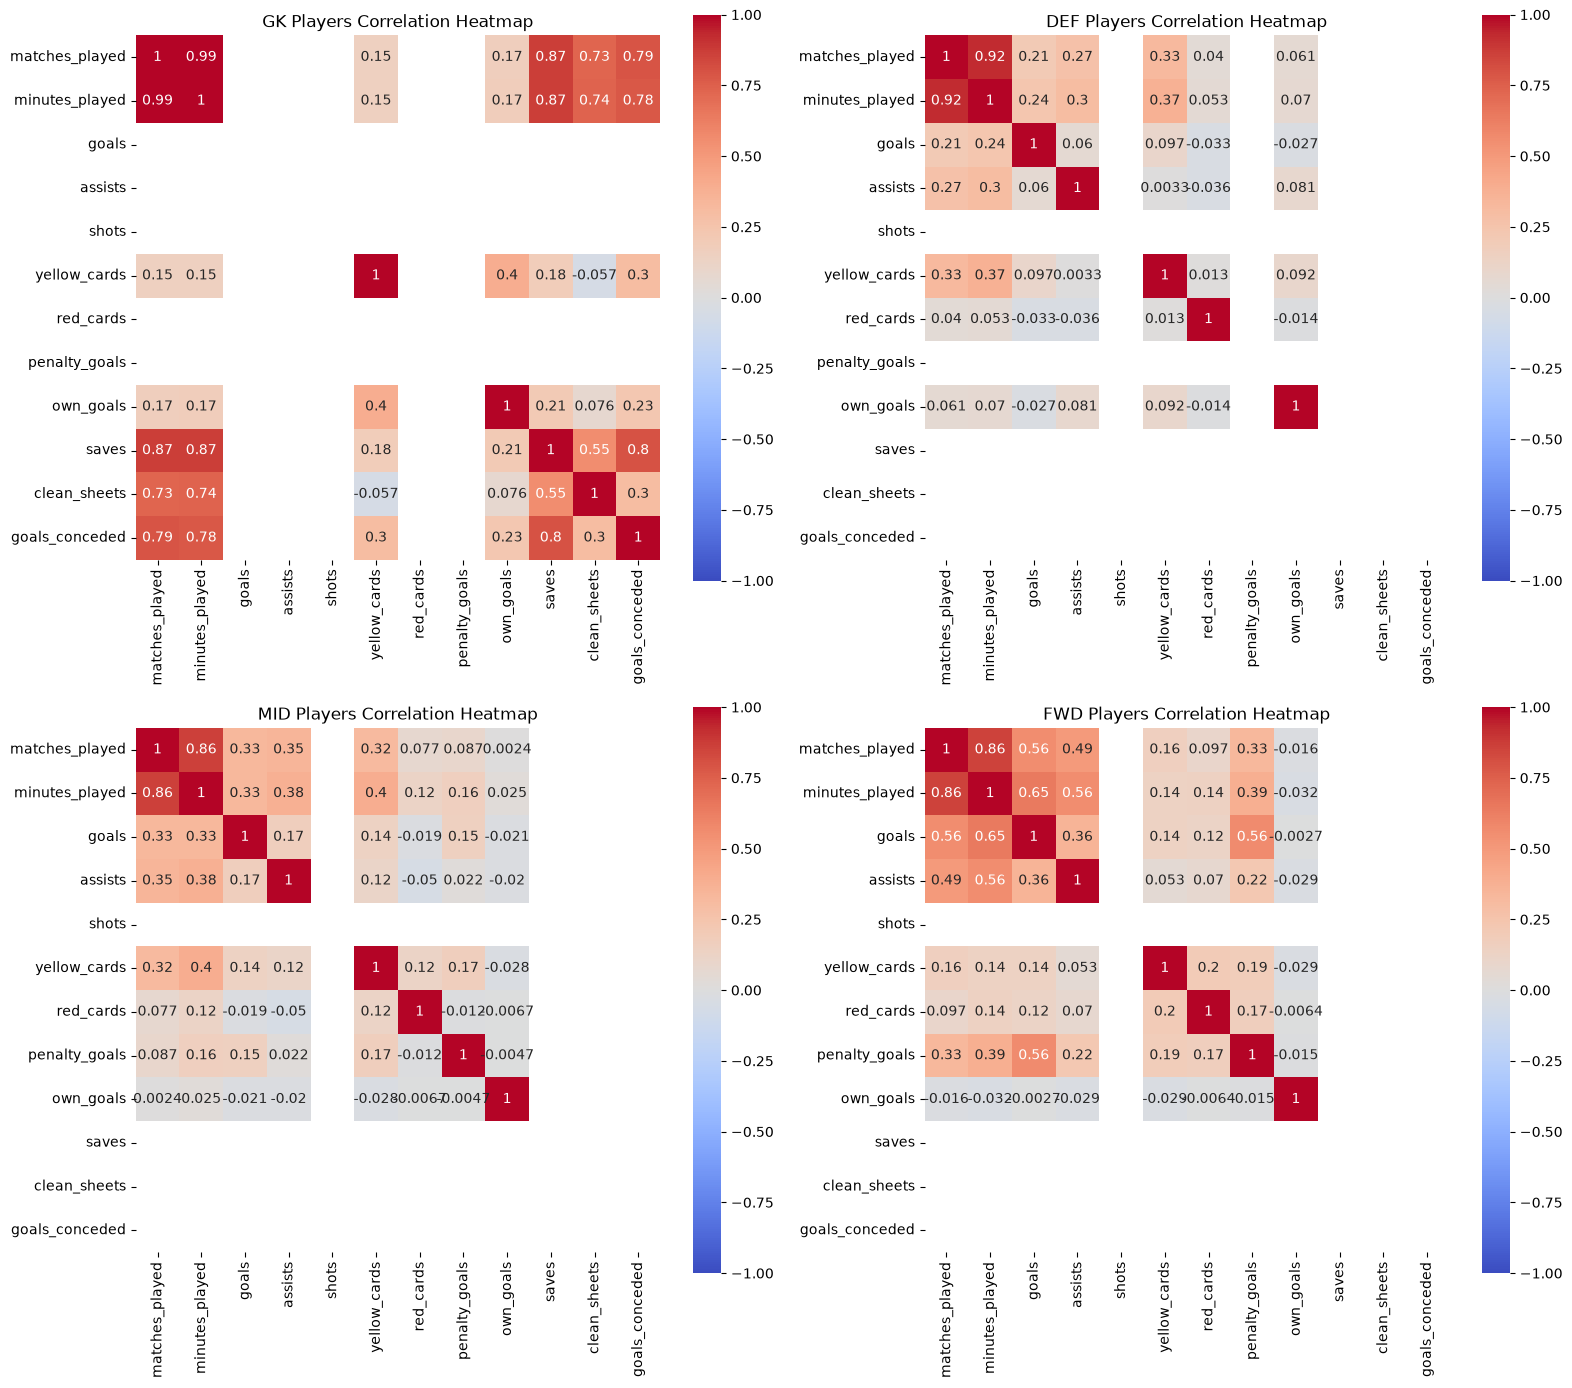

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# GK Players
corr_gk = GK_players[numeric_col].corr()
sns.heatmap(corr_gk, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[0, 0])
axes[0, 0].set_title('GK Players Correlation Heatmap')

# DEF Players
corr_def = DEF_players[numeric_col].corr()
sns.heatmap(corr_def, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[0, 1])
axes[0, 1].set_title('DEF Players Correlation Heatmap')

# MID Players
corr_mid = MID_players[numeric_col].corr()
sns.heatmap(corr_mid, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[1, 0])
axes[1, 0].set_title('MID Players Correlation Heatmap')

# FWD Players
corr_fwd = FWD_players[numeric_col].corr()
sns.heatmap(corr_fwd, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[1, 1])
axes[1, 1].set_title('FWD Players Correlation Heatmap')

plt.tight_layout()
plt.show()


Create function to standardize data and extract the first principal component (PC1) for player ranking.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def run_pca_1_component(df, numeric_cols):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[numeric_cols])

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(X_scaled)

    result = df.copy()
    result['PC1'] = pc1[:, 0]
    result['ExplainedVar_PC1'] = pca.explained_variance_ratio_[0]
    loadings = pd.Series(pca.components_[0], index=numeric_cols)
    print(loadings)

    return result


Apply PCA to goalkeepers and rank them by PC1 score within each team.

In [9]:
GK_pca  = run_pca_1_component(GK_players, numeric_col)
GK_pca = GK_pca.sort_values(by=['team_name','PC1'], ascending=[True, False])
GK_pca['nation_counter'] = GK_pca.groupby('team_name').cumcount() + 1
GK_pca ['graph'] = GK_pca['position'] + GK_pca['nation_counter'].astype(str)
GK_pca

matches_played    0.481518
minutes_played    0.481065
goals            -0.000000
assists          -0.000000
shots            -0.000000
yellow_cards      0.125802
red_cards        -0.000000
penalty_goals    -0.000000
own_goals         0.139002
saves             0.454600
clean_sheets      0.349106
goals_conceded    0.415971
dtype: float64


,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name,PC1,ExplainedVar_PC1,nation_counter,graph
984,985,Luca Zinedine Zidane,38,GK,3,3,270,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,1.257809,0.587773,1,GK1
977,978,Oussama Benbot,38,GK,1,1,90,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-0.591474,0.587773,2,GK2
962,963,Melvin Feycal Mastil,38,GK,0,0,0,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-1.465684,0.587773,3,GK3
958,959,Damián Emiliano Martinez,37,GK,8,8,810,0,0,0.0,...,ARG,J,CONMEBOL,1,2150,Lionel Scaloni,5.732682,0.587773,1,GK1
936,937,Juan Agustín Musso,37,GK,0,0,0,0,0,0.0,...,ARG,J,CONMEBOL,1,2150,Lionel Scaloni,-1.465684,0.587773,2,GK2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,807,Sergio Ramón Rochet,32,GK,1,0,44,0,0,0.0,...,URU,H,CONMEBOL,16,1960,Marcelo Bielsa,-1.124379,0.587773,2,GK2
817,818,Santiago Andres Mele,32,GK,0,0,0,0,0,0.0,...,URU,H,CONMEBOL,16,1960,Marcelo Bielsa,-1.465684,0.587773,3,GK3
1103,1104,Abduvakhid Nematov,43,GK,2,2,180,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,0.821654,0.587773,1,GK1
1092,1093,Utkir Yusupov,43,GK,1,1,90,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-0.201800,0.587773,2,GK2


Apply PCA to defenders and rank them by PC1 score within each team.

In [10]:
DEF_pca = run_pca_1_component(DEF_players, numeric_col)
DEF_pca = DEF_pca.sort_values(by=['team_name','PC1'], ascending=[True, False])
DEF_pca['nation_counter'] = DEF_pca.groupby('team_name').cumcount() + 1
DEF_pca ['graph'] = DEF_pca['position'] + DEF_pca['nation_counter'].astype(str)
DEF_pca

matches_played    6.022972e-01
minutes_played    6.170400e-01
goals             2.352487e-01
assists           2.731707e-01
shots            -1.084202e-19
yellow_cards      3.414215e-01
red_cards         3.178553e-02
penalty_goals    -0.000000e+00
own_goals         9.463910e-02
saves            -0.000000e+00
clean_sheets     -0.000000e+00
goals_conceded   -0.000000e+00
dtype: float64


,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name,PC1,ExplainedVar_PC1,nation_counter,graph
978,979,Rafik Belghali,38,DEF,4,4,333,1,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,1.503277,0.334631,1,DEF1
963,964,Aissa Mandi,38,DEF,4,4,360,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,0.784555,0.334631,2,DEF2
982,983,Selmane Rami Bensebaini,38,DEF,4,4,341,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,0.713841,0.334631,3,DEF3
976,977,Rayan Ait-Nouri,38,DEF,4,3,284,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,0.501701,0.334631,4,DEF4
974,975,Jaouen Djimmy Hadjam,38,DEF,3,1,108,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-0.475260,0.334631,5,DEF5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,1095,Khojiakbar Alijonov,43,DEF,2,1,134,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-0.700427,0.334631,6,DEF6
1117,1118,Jakhongir Urozov,43,DEF,2,1,95,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-0.845575,0.334631,7,DEF7
1095,1096,Farrukh Sayfiev,43,DEF,1,0,44,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-1.357317,0.334631,8,DEF8
1106,1107,Umarbek Eshmurodov,43,DEF,0,0,0,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-1.843007,0.334631,9,DEF9


Apply PCA to forwards and rank them by PC1 score within each team.

In [11]:
FWD_pca = run_pca_1_component(FWD_players, numeric_col)
FWD_pca = FWD_pca.sort_values(by=['team_name','PC1'], ascending=[True, False])
FWD_pca['nation_counter'] = FWD_pca.groupby('team_name').cumcount() + 1
FWD_pca ['graph'] = FWD_pca['position'] + FWD_pca['nation_counter'].astype(str)
FWD_pca

matches_played    0.482830
minutes_played    0.510282
goals             0.453830
assists           0.367117
shots            -0.000000
yellow_cards      0.152218
red_cards         0.136741
penalty_goals     0.351300
own_goals        -0.021709
saves            -0.000000
clean_sheets     -0.000000
goals_conceded   -0.000000
dtype: float64


,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name,PC1,ExplainedVar_PC1,nation_counter,graph
968,969,Riyad Karim Mahrez,38,FWD,4,3,282,2,2,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,1.934232,0.391716,1,FWD1
970,971,Amine Ferid Gouiri,38,FWD,4,3,253,1,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,0.567285,0.391716,2,FWD2
972,973,Anis Hadj Moussa,38,FWD,3,1,97,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-0.598951,0.391716,3,FWD3
973,974,Ahmed Nadhir Benbouali,38,FWD,1,0,45,1,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-0.961885,0.391716,4,FWD4
981,982,Adil Boulbina,38,FWD,2,0,16,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-1.148698,0.391716,5,FWD5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
824,825,Rodrigo Sebastian Aguirre,32,FWD,1,0,1,0,0,0.0,...,URU,H,CONMEBOL,16,1960,Marcelo Bielsa,-1.472024,0.391716,4,FWD4
816,817,Facundo Pellistri,32,FWD,0,0,0,0,0,0.0,...,URU,H,CONMEBOL,16,1960,Marcelo Bielsa,-1.747321,0.391716,5,FWD5
1105,1106,Eldor Shomurodov,43,FWD,3,3,270,1,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,0.353740,0.391716,1,FWD1
1112,1113,Igor Sergeev,43,FWD,3,0,26,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-0.842526,0.391716,2,FWD2


Apply PCA to midfielders and rank them by PC1 score within each team.

In [12]:
MID_pca = run_pca_1_component(MID_players, numeric_col)
MID_pca = MID_pca.sort_values(by=['team_name','PC1'], ascending=[True, False])
MID_pca['nation_counter'] = MID_pca.groupby('team_name').cumcount() + 1
MID_pca['graph'] = MID_pca['position'] + MID_pca['nation_counter'].astype(str)
MID_pca

matches_played    0.552226
minutes_played    0.573762
goals             0.325303
assists           0.329303
shots            -0.000000
yellow_cards      0.342547
red_cards         0.085014
penalty_goals     0.164256
own_goals        -0.005909
saves            -0.000000
clean_sheets     -0.000000
goals_conceded   -0.000000
dtype: float64


,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name,PC1,ExplainedVar_PC1,nation_counter,graph
971,972,Fares Chaibi,38,MID,4,4,360,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,1.152981,0.316967,1,MID1
969,970,Houssem-Eddine Chaabane Aouar,38,MID,3,2,174,0,2,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,0.786973,0.316967,2,MID2
983,984,Ibrahim Maza,38,MID,4,4,352,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,0.505545,0.316967,3,MID3
980,981,Nabil Bentaleb,38,MID,4,3,288,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,0.264793,0.316967,4,MID4
975,976,Hicham Boudaoui,38,MID,3,2,128,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-0.022902,0.316967,5,MID5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1108,1109,Dostonbek Khamdamov,43,MID,2,1,102,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-1.041208,0.316967,6,MID6
1102,1103,Oston Urunov,43,MID,2,1,63,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-1.187916,0.316967,7,MID7
1099,1100,Jamshid Iskanderov,43,MID,1,0,8,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-1.697970,0.316967,8,MID8
1101,1102,Ruslanbek Jiyanov,43,MID,1,0,1,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-1.724303,0.316967,9,MID9


Merge all position-specific PCA results into a single comprehensive dataset.

In [16]:

all_pca = pd.concat([GK_pca, DEF_pca, MID_pca, FWD_pca], ignore_index=True)
all_pca

,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name,PC1,ExplainedVar_PC1,nation_counter,graph
0,985,Luca Zinedine Zidane,38,GK,3,3,270,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,1.257809,0.587773,1,GK1
1,978,Oussama Benbot,38,GK,1,1,90,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-0.591474,0.587773,2,GK2
2,963,Melvin Feycal Mastil,38,GK,0,0,0,0,0,0.0,...,ALG,J,CAF,28,1760,Vladimir Petković,-1.465684,0.587773,3,GK3
3,959,Damián Emiliano Martinez,37,GK,8,8,810,0,0,0.0,...,ARG,J,CONMEBOL,1,2150,Lionel Scaloni,5.732682,0.587773,1,GK1
4,937,Juan Agustín Musso,37,GK,0,0,0,0,0,0.0,...,ARG,J,CONMEBOL,1,2150,Lionel Scaloni,-1.465684,0.587773,2,GK2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,825,Rodrigo Sebastian Aguirre,32,FWD,1,0,1,0,0,0.0,...,URU,H,CONMEBOL,16,1960,Marcelo Bielsa,-1.472024,0.391716,4,FWD4
1244,817,Facundo Pellistri,32,FWD,0,0,0,0,0,0.0,...,URU,H,CONMEBOL,16,1960,Marcelo Bielsa,-1.747321,0.391716,5,FWD5
1245,1106,Eldor Shomurodov,43,FWD,3,3,270,1,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,0.353740,0.391716,1,FWD1
1246,1113,Igor Sergeev,43,FWD,3,0,26,0,0,0.0,...,UZB,K,AFC,50,1650,Fabio Cannavaro,-0.842526,0.391716,2,FWD2


Filter the top-ranked players from each position (GK1, DEF1-3, MID1-4, FWD1-3) for visualization purposes.

In [14]:
# import openpyxl
graph_data = all_pca[['player_name','player_id','team_id','PC1','graph']]
graph_data = graph_data[( graph_data['graph'] == 'GK1') |
                        ( graph_data['graph'] == 'DEF1') |
                        ( graph_data['graph'] == 'DEF2') |
                        (graph_data['graph'] == 'DEF3') |
                        ( graph_data['graph'] == 'MID1') |
                        (graph_data['graph'] == 'MID2') |
                        (graph_data['graph'] == 'MID3') |
                        (graph_data['graph'] == 'MID4') |
                        ( graph_data['graph'] == 'FWD1')|
                         ( graph_data['graph'] == 'FWD2') |
                        ( graph_data['graph'] == 'FWD3')]
# graph_data.to_excel('graph_data.xlsx', index=False)


Generate API URLs for player photos using their player IDs from Sofascore.

In [1]:
all_pca [ 'URL_photo'] = 'https://api.sofascore.com/api/v1/player/' + all_pca['player_id'].astype(str) + '/image'
# all_pca.to_excel('all_pca.xlsx', index=False)
all_pca

NameError: name 'all_pca' is not defined